In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =============================================================================
# CRI-XAI PROJECT — NUOVO R_i (target = r_i, Sezione 3.2-3.3 del paper)
# + Validazione SAFE AI con il pacchetto UFFICIALE degli autori (Babaei et al.)
#
# Input: campione_individuale_r_i.csv (generato dalla microsimulazione, Cella 7)
# Output: modello R_i, pesi Shapley per C_i, metriche di validazione SAFE AI
#
# NOTA SU CENSIMENTO: se Fabio trova il dato censuario, questo script NON
# cambia — si rilancia identico, ripuntato al nuovo campione_individuale_r_i.csv
# rigenerato con EDUCATION_SOURCE="censimento" nello script di microsimulazione.
# =============================================================================


# %% CELL 1 — Installazione pacchetti + caricamento dati
# =============================================================================
!pip install safeaipackage shap catboost xgboost -q

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PATH_CAMPIONE = '/content/drive/MyDrive/Paper ASMBI/Dataset/campione_individuale_r_i.csv'
df = pd.read_csv(PATH_CAMPIONE)

print(f"Campione caricato: {len(df):,} righe")

# --- NUOVO: aggiungiamo la dimensione del comune come feature ---
# Il paper (abstract) dice esplicitamente che il rischio è "dictated by
# population density" — mancava completamente dalle feature di R_i. Non serve
# rigenerare la microsimulazione: il dato è già nel file comunale, basta unirlo
# tramite Comune_Codice / Codice.comune.
PATH_COMUNI = '/content/drive/MyDrive/Paper ASMBI/Dataset/dataset_random_forest_completo.csv'
df_comuni_size = pd.read_csv(PATH_COMUNI, sep=None, engine='python')[['Codice.comune', 'Numero contribuenti']]
df_comuni_size = df_comuni_size.rename(columns={'Codice.comune': 'Comune_Codice',
                                                  'Numero contribuenti': 'Numero_contribuenti'})

righe_prima = len(df)
df = df.merge(df_comuni_size, on='Comune_Codice', how='left')
righe_senza_match = df['Numero_contribuenti'].isna().sum()
print(f"Righe senza corrispondenza comunale: {righe_senza_match} su {righe_prima}")
if righe_senza_match > 0:
    df = df.dropna(subset=['Numero_contribuenti'])
    print(f"Rimosse — restano {len(df):,} righe")

print(df[['Comune_Codice', 'Region', 'Gender', 'Age', 'Education_Macro',
          'Total_Gross_Income', 'Numero_contribuenti', 'r_i']].head())
print(f"\nDistribuzione r_i:\n{df['r_i'].describe()}")


# %% CELL 2 — TEST SU CAMPIONE PICCOLO (prima di tutto il dataset)
# =============================================================================
# Come per la microsimulazione, testiamo la pipeline su un sottoinsieme
# piccolo prima di lanciarla su tutto (~1,1-1,2 milioni di righe).
N_TEST = 20_000
df_test = df.sample(N_TEST, random_state=RANDOM_STATE).copy()
print(f"Campione di test: {len(df_test):,} righe — usalo per validare la pipeline "
      f"prima di passare a N_TRAIN più grande nella Cella 3.")

Campione caricato: 779,965 righe
Righe senza corrispondenza comunale: 0 su 779965
   Comune_Codice    Region Gender  Age Education_Macro  Total_Gross_Income  \
0           1001  Piemonte      M   37         1_Medio        22192.426617   
1           1001  Piemonte      M   85          0_Base         4480.602919   
2           1001  Piemonte      M   84          0_Base        20999.669191   
3           1001  Piemonte      M   62          2_Alto        73014.223870   
4           1001  Piemonte      F   58          2_Alto        89263.531494   

   Numero_contribuenti       r_i  
0                 1963  0.002825  
1                 1963  0.002841  
2                 1963  0.002841  
3                 1963  0.033333  
4                 1963  0.004545  

Distribuzione r_i:
count    779965.000000
mean          0.006735
std           0.033380
min           0.000002
25%           0.000805
50%           0.001838
75%           0.004237
max           1.000000
Name: r_i, dtype: float64
Campione 

In [ ]:
# %% CELL 3 — Preparazione feature e training del nuovo R_i
# =============================================================================
# Per il training vero, usa un campione più ampio (es. 300.000-500.000 righe):
# sufficiente per un Random Forest solido, molto più veloce di 1,2M righe intere.
N_TRAIN = 300_000
df_model = df.sample(min(N_TRAIN, len(df)), random_state=RANDOM_STATE).copy()

# One-hot encoding delle categoriche (Region, Gender, Education_Macro) —
# preferito al Label Encoding qui perché rende più semplice ricomporre i pesi
# Shapley per variabile originale nella Cella 4 (Sezione 3.3 del paper:
# "Symmetry" e "Additivity" si applicano più naturalmente su dummy separate).
X = pd.get_dummies(
    df_model[['Region', 'Gender', 'Age', 'Education_Macro', 'Total_Gross_Income', 'Numero_contribuenti']],
    columns=['Region', 'Gender', 'Education_Macro'],
    drop_first=False
)
y = df_model['r_i']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

rf_ri = RandomForestRegressor(
    n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
rf_ri.fit(X_train, y_train)

y_pred = rf_ri.predict(X_test)
print(f"R² sul test set: {r2_score(y_test, y_pred):.4f}")
print(f"MAE sul test set: {mean_absolute_error(y_test, y_pred):.6f}")
print("(r_i è quasi sempre vicino a 0, quindi un MAE piccolo in valore assoluto "
      "è atteso — guarda soprattutto R² per la bontà del modello)")


# %% CELL 4 — Pesi Shapley per R_i (Sezione 3.3 del paper)
# =============================================================================
import shap

explainer = shap.TreeExplainer(rf_ri)
# Su un campione del test set, non tutto — SHAP è costoso, e per i pesi
# aggregati di R_i basta un campione rappresentativo
X_shap_sample = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap_sample)

# Importanza media assoluta per ciascuna colonna one-hot
shap_importance = pd.DataFrame({
    'feature_encoded': X_shap_sample.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
})

# Ricomponiamo le colonne one-hot nella variabile originale (es. tutte le
# Region_* sommate in "Region"), coerente con l'assioma di Additività (Sez. 3.3)
def variabile_originale(col):
    for base in ['Region', 'Gender', 'Education_Macro']:
        if col.startswith(base + '_'):
            return base
    return col  # Age, Total_Gross_Income restano come sono

shap_importance['feature'] = shap_importance['feature_encoded'].apply(variabile_originale)
pesi_ri = shap_importance.groupby('feature')['mean_abs_shap'].sum().reset_index()
pesi_ri['importance_norm'] = pesi_ri['mean_abs_shap'] / pesi_ri['mean_abs_shap'].sum()
pesi_ri = pesi_ri.sort_values('importance_norm', ascending=False)

print("Pesi Shapley aggregati per R_i:")
print(pesi_ri[['feature', 'importance_norm']])

# Salvataggio — sostituisce feature_importances_RF.csv nel flusso verso R
PATH_PESI_OUTPUT = '/content/drive/MyDrive/Paper ASMBI/Dataset/feature_importances_SHAP_ri.csv'
pesi_ri[['feature', 'importance_norm']].to_csv(PATH_PESI_OUTPUT, index=False)
print(f"\n✅ Salvato: {PATH_PESI_OUTPUT}")


# %% CELL 5 — Validazione SAFE AI con il PACCHETTO UFFICIALE (non più a mano)
# =============================================================================
# IMPORTANTE (scoperto leggendo il codice sorgente vero di safeaipackage):
# la funzione interna manipulate_testdata decide se sostituire una variabile
# con la MEDIA o con la MODA guardando se la colonna è di tipo pandas
# 'category'. Con il one-hot encoding della Cella 3/4 (colonne 0/1 per ogni
# regione), verrebbe usata la media su ciascuna dummy — concettualmente sbagliato
# per una categoriale. Serve quindi un modello SEPARATO, più semplice, con le
# categoriali codificate come interi ma esplicitamente marcate come 'category',
# così RGE/RGF/RGR interpretano correttamente "la variabile Region nel suo
# insieme", non frammentata in dummy.
from sklearn.preprocessing import OrdinalEncoder

X_cat = df_model[['Region', 'Gender', 'Age', 'Education_Macro', 'Total_Gross_Income', 'Numero_contribuenti']].copy()
oe = OrdinalEncoder()
X_cat[['Region', 'Gender', 'Education_Macro']] = oe.fit_transform(
    X_cat[['Region', 'Gender', 'Education_Macro']]
).astype(int)
# Marcatura esplicita come 'category': è questo che fa scattare la sostituzione
# con la MODA (non la media) dentro manipulate_testdata
for col in ['Region', 'Gender', 'Education_Macro']:
    X_cat[col] = X_cat[col].astype('category')

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y, test_size=0.2, random_state=RANDOM_STATE
)

# Un Random Forest sklearn non accetta dtype 'category' nativamente in fit():
# lo passiamo come int per l'addestramento, poi ripristiniamo il dtype
# 'category' sui dataframe usati SOLO per le chiamate a safeaipackage
rf_ri_cat = RandomForestRegressor(
    n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
rf_ri_cat.fit(X_train_cat.astype({c: 'int' for c in ['Region', 'Gender', 'Education_Macro']}),
              y_train_cat)
y_pred_cat = rf_ri_cat.predict(
    X_test_cat.astype({c: 'int' for c in ['Region', 'Gender', 'Education_Macro']})
)
print(f"R² del modello di validazione (encoding categoriale): {r2_score(y_test_cat, y_pred_cat):.4f}")
print("(atteso vicino, ma non identico, a quello della Cella 3 — è un modello "
      "diverso, con encoding diverso, usato solo per la validazione SAFE AI)")


from sklearn.base import BaseEstimator, RegressorMixin

class ModelloConCastAutomatico(RegressorMixin, BaseEstimator):
    """
    Le funzioni di safeaipackage (manipulate_testdata, perturb) passano a
    model.predict() un dataframe dove le colonne categoriali restano di tipo
    'category'. Non è garantito che ogni versione di scikit-learn lo accetti
    senza errori — questo wrapper converte sempre in int prima di predire,
    così la compatibilità è garantita indipendentemente dalla versione.
    Eredita da (RegressorMixin, BaseEstimator), IN QUEST'ORDINE: è l'ordine
    convenzionale di scikit-learn — RegressorMixin prima, BaseEstimator dopo —
    necessario perché is_regressor() (usata internamente da safeaipackage)
    riconosca correttamente il wrapper come regressore. Verificato: con
    l'ordine invertito is_regressor() restituisce False silenziosamente.
    """
    def __init__(self, modello, colonne_categoriali):
        self.modello = modello
        self.colonne_categoriali = colonne_categoriali

    def predict(self, X):
        X_safe = X.copy()
        for c in self.colonne_categoriali:
            if c in X_safe.columns:
                X_safe[c] = X_safe[c].astype(int)
        return self.modello.predict(X_safe)

    def predict_proba(self, X):
        X_safe = X.copy()
        for c in self.colonne_categoriali:
            if c in X_safe.columns:
                X_safe[c] = X_safe[c].astype(int)
        return self.modello.predict_proba(X_safe)


rf_ri_cat_safe = ModelloConCastAutomatico(rf_ri_cat, ['Region', 'Gender', 'Education_Macro'])

from safeaipackage.core import rga
from safeaipackage.check_explainability import compute_rge_values
from safeaipackage.check_fairness import compute_rga_parity
from safeaipackage.check_robustness import compute_rgr_values

variabili_cat = ['Region', 'Gender', 'Age', 'Education_Macro', 'Total_Gross_Income', 'Numero_contribuenti']

# --- RGA: metrica di accuratezza di base ---
rga_score = rga(y_test_cat.values, y_pred_cat)
print(f"\nRGA (accuratezza base): {rga_score:.4f}")

# --- RGE: Explainability — ora una riga per variabile ORIGINALE, non per dummy ---
rge_values = compute_rge_values(
    xtrain=X_train_cat, xtest=X_test_cat, yhat=y_pred_cat, model=rf_ri_cat_safe,
    variables=variabili_cat, group=False
)
print("\nRGE (Explainability) per variabile:")
print(rge_values)

# --- RGF: Fairness — parità tra i generi ---
rgf_score = compute_rga_parity(
    xtrain=X_train_cat, xtest=X_test_cat, ytest=y_test_cat, yhat=y_pred_cat,
    model=rf_ri_cat_safe, protectedvariable='Gender'
)
print(f"\nRGF (Fairness, parità di genere): {rgf_score}")

# --- RGR: Robustness — stabilità a perturbazioni dell'input ---
rgr_values = compute_rgr_values(
    xtest=X_test_cat, yhat=y_pred_cat, model=rf_ri_cat_safe,
    variables=variabili_cat, perturbation_percentage=0.05, group=False
)
print("\nRGR (Robustness) per variabile:")
print(rgr_values)

print("\n✅ Validazione SAFE AI completata con il pacchetto ufficiale, codice sorgente verificato.")

NameError: name 'df' is not defined

Proviamo a usare un campione di 600000 in modo da vedere se cambia in modo sostanziale R^2

In [ ]:
# =============================================================================
# CRI-XAI PROJECT — NUOVO R_i (target = r_i, Sezione 3.2-3.3 del paper)
# + Validazione SAFE AI con il pacchetto UFFICIALE degli autori (Babaei et al.)
#
# Input: campione_individuale_r_i.csv (generato dalla microsimulazione, Cella 7)
# Output: modello R_i, pesi Shapley per C_i, metriche di validazione SAFE AI
#
# NOTA SU CENSIMENTO: se Fabio trova il dato censuario, questo script NON
# cambia — si rilancia identico, ripuntato al nuovo campione_individuale_r_i.csv
# rigenerato con EDUCATION_SOURCE="censimento" nello script di microsimulazione.
# =============================================================================


# %% CELL 1 — Installazione pacchetti + caricamento dati
# =============================================================================
!pip install safeaipackage shap catboost xgboost -q

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PATH_CAMPIONE = '/content/drive/MyDrive/Paper ASMBI/Dataset/campione_individuale_r_i.csv'
df = pd.read_csv(PATH_CAMPIONE)

print(f"Campione caricato: {len(df):,} righe")

# --- NUOVO: aggiungiamo la dimensione del comune come feature ---
# Il paper (abstract) dice esplicitamente che il rischio è "dictated by
# population density" — mancava completamente dalle feature di R_i. Non serve
# rigenerare la microsimulazione: il dato è già nel file comunale, basta unirlo
# tramite Comune_Codice / Codice.comune.
PATH_COMUNI = '/content/drive/MyDrive/Paper ASMBI/Dataset/dataset_random_forest_completo.csv'
df_comuni_size = pd.read_csv(PATH_COMUNI, sep=None, engine='python')[['Codice.comune', 'Numero contribuenti']]
df_comuni_size = df_comuni_size.rename(columns={'Codice.comune': 'Comune_Codice',
                                                  'Numero contribuenti': 'Numero_contribuenti'})

righe_prima = len(df)
df = df.merge(df_comuni_size, on='Comune_Codice', how='left')
righe_senza_match = df['Numero_contribuenti'].isna().sum()
print(f"Righe senza corrispondenza comunale: {righe_senza_match} su {righe_prima}")
if righe_senza_match > 0:
    df = df.dropna(subset=['Numero_contribuenti'])
    print(f"Rimosse — restano {len(df):,} righe")

print(df[['Comune_Codice', 'Region', 'Gender', 'Age', 'Education_Macro',
          'Total_Gross_Income', 'Numero_contribuenti', 'r_i']].head())
print(f"\nDistribuzione r_i:\n{df['r_i'].describe()}")


# %% CELL 2 — TEST SU CAMPIONE PICCOLO (prima di tutto il dataset)
# =============================================================================
# Come per la microsimulazione, testiamo la pipeline su un sottoinsieme
# piccolo prima di lanciarla su tutto (~1,1-1,2 milioni di righe).
N_TEST = 20_000
df_test = df.sample(N_TEST, random_state=RANDOM_STATE).copy()
print(f"Campione di test: {len(df_test):,} righe — usalo per validare la pipeline "
      f"prima di passare a N_TRAIN più grande nella Cella 3.")


# %% CELL 3 — Preparazione feature e training del nuovo R_i
# =============================================================================
# Per il training vero, usa un campione più ampio (es. 300.000-500.000 righe):
# sufficiente per un Random Forest solido, molto più veloce di 1,2M righe intere.
#
# CONTROLLO DI CONFERMA: confrontiamo N_TRAIN=300k (già fatto) con 600k, per
# verificare se vale la pena usare più dati o se il modello ha già raggiunto
# il suo plateau (comportamento tipico dei Random Forest oltre una certa soglia).
def addestra_e_valuta(n_train, df_full, random_state=42):
    df_model = df_full.sample(min(n_train, len(df_full)), random_state=random_state).copy()
    X = pd.get_dummies(
        df_model[['Region', 'Gender', 'Age', 'Education_Macro', 'Total_Gross_Income', 'Numero_contribuenti']],
        columns=['Region', 'Gender', 'Education_Macro'],
        drop_first=False
    )
    y = df_model['r_i']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )
    rf = RandomForestRegressor(
        n_estimators=300, max_depth=12, random_state=random_state, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    return rf, X, y, X_train, X_test, y_train, y_test, y_pred, r2

import time

print("Training con N_TRAIN=300.000 (quello già fatto, lo rifacciamo per il confronto diretto)...")
t0 = time.time()
rf_300k, X_300k, y_300k, X_train_300k, X_test_300k, y_train_300k, y_test_300k, y_pred_300k, r2_300k = \
    addestra_e_valuta(300_000, df)
print(f"R² con 300k righe: {r2_300k:.4f} — tempo: {(time.time()-t0)/60:.1f} minuti")

print("\nTraining con N_TRAIN=600.000...")
t0 = time.time()
rf_600k, X_600k, y_600k, X_train_600k, X_test_600k, y_train_600k, y_test_600k, y_pred_600k, r2_600k = \
    addestra_e_valuta(600_000, df)
print(f"R² con 600k righe: {r2_600k:.4f} — tempo: {(time.time()-t0)/60:.1f} minuti")

differenza = r2_600k - r2_300k
print(f"\nDifferenza di R²: {differenza:+.4f}")
if abs(differenza) < 0.01:
    print("✅ Differenza trascurabile (<0.01) — 300k righe erano già sufficienti, "
          "conviene restare su quella scala per velocità nei prossimi step.")
    rf_ri, X, y, X_train, X_test, y_train, y_test, y_pred = \
        rf_300k, X_300k, y_300k, X_train_300k, X_test_300k, y_train_300k, y_test_300k, y_pred_300k
    df_model = df.sample(300_000, random_state=RANDOM_STATE).copy()
else:
    print("⚠️ Differenza non trascurabile — conviene usare 600k (o più) come base "
          "definitiva per i pesi Shapley e la validazione SAFE AI.")
    rf_ri, X, y, X_train, X_test, y_train, y_test, y_pred = \
        rf_600k, X_600k, y_600k, X_train_600k, X_test_600k, y_train_600k, y_test_600k, y_pred_600k
    df_model = df.sample(600_000, random_state=RANDOM_STATE).copy()

print(f"\nR² finale scelto: {r2_score(y_test, y_pred):.4f}")
print(f"MAE finale: {mean_absolute_error(y_test, y_pred):.6f}")


# %% CELL 4 — Pesi Shapley per R_i (Sezione 3.3 del paper)
# =============================================================================
import shap

explainer = shap.TreeExplainer(rf_ri)
# Su un campione del test set, non tutto — SHAP è costoso, e per i pesi
# aggregati di R_i basta un campione rappresentativo
X_shap_sample = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap_sample)

# Importanza media assoluta per ciascuna colonna one-hot
shap_importance = pd.DataFrame({
    'feature_encoded': X_shap_sample.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
})

# Ricomponiamo le colonne one-hot nella variabile originale (es. tutte le
# Region_* sommate in "Region"), coerente con l'assioma di Additività (Sez. 3.3)
def variabile_originale(col):
    for base in ['Region', 'Gender', 'Education_Macro']:
        if col.startswith(base + '_'):
            return base
    return col  # Age, Total_Gross_Income restano come sono

shap_importance['feature'] = shap_importance['feature_encoded'].apply(variabile_originale)
pesi_ri = shap_importance.groupby('feature')['mean_abs_shap'].sum().reset_index()
pesi_ri['importance_norm'] = pesi_ri['mean_abs_shap'] / pesi_ri['mean_abs_shap'].sum()
pesi_ri = pesi_ri.sort_values('importance_norm', ascending=False)

print("Pesi Shapley aggregati per R_i:")
print(pesi_ri[['feature', 'importance_norm']])

# Salvataggio — sostituisce feature_importances_RF.csv nel flusso verso R
PATH_PESI_OUTPUT = '/content/drive/MyDrive/Paper ASMBI/Dataset/feature_importances_SHAP_ri.csv'
pesi_ri[['feature', 'importance_norm']].to_csv(PATH_PESI_OUTPUT, index=False)
print(f"\n✅ Salvato: {PATH_PESI_OUTPUT}")


# %% CELL 4bis — Direzione dell'effetto (segno), non solo magnitudine
# =============================================================================
# I valori di Shapley hanno già un segno, calcolato nella Cella 4 (shap_values):
# positivo = spinge r_i verso l'alto (più rischio), negativo = verso il basso.
# Qui lo estraiamo esplicitamente, distinguendo variabili continue e categoriali.

print("=== VARIABILI CONTINUE: direzione tramite correlazione feature-valore/SHAP ===")
variabili_continue = ['Age', 'Total_Gross_Income', 'Numero_contribuenti']
for var in variabili_continue:
    if var in X_shap_sample.columns:
        corr = np.corrcoef(X_shap_sample[var].values,
                            shap_values[:, X_shap_sample.columns.get_loc(var)])[0, 1]
        direzione = "AUMENTA il rischio quando cresce" if corr > 0 else "DIMINUISCE il rischio quando cresce"
        print(f"{var}: correlazione feature/SHAP = {corr:+.3f} → {direzione}")

print("\n=== VARIABILI CATEGORIALI: SHAP medio quando la categoria è presente ===")
for base in ['Region', 'Gender', 'Education_Macro']:
    cols_categoria = [c for c in X_shap_sample.columns if c.startswith(base + '_')]
    print(f"\n--- {base} ---")
    risultati_categoria = []
    for col in cols_categoria:
        mask = X_shap_sample[col].values == 1
        if mask.sum() > 0:
            shap_medio = shap_values[mask, X_shap_sample.columns.get_loc(col)].mean()
            risultati_categoria.append((col.replace(base + '_', ''), shap_medio))
    risultati_categoria.sort(key=lambda x: x[1], reverse=True)
    for nome_categoria, shap_medio in risultati_categoria:
        segno = "aumenta" if shap_medio > 0 else "diminuisce"
        print(f"  {nome_categoria}: SHAP medio = {shap_medio:+.5f} ({segno} il rischio)")

print("\n✅ Direzione degli effetti estratta — utile per la discussione nel Capitolo 5:")
print("   non solo QUALI variabili contano di più, ma in che VERSO agiscono.")


# %% CELL 5 — Validazione SAFE AI con il PACCHETTO UFFICIALE (non più a mano)
# =============================================================================
# IMPORTANTE (scoperto leggendo il codice sorgente vero di safeaipackage):
# la funzione interna manipulate_testdata decide se sostituire una variabile
# con la MEDIA o con la MODA guardando se la colonna è di tipo pandas
# 'category'. Con il one-hot encoding della Cella 3/4 (colonne 0/1 per ogni
# regione), verrebbe usata la media su ciascuna dummy — concettualmente sbagliato
# per una categoriale. Serve quindi un modello SEPARATO, più semplice, con le
# categoriali codificate come interi ma esplicitamente marcate come 'category',
# così RGE/RGF/RGR interpretano correttamente "la variabile Region nel suo
# insieme", non frammentata in dummy.
from sklearn.preprocessing import OrdinalEncoder

X_cat = df_model[['Region', 'Gender', 'Age', 'Education_Macro', 'Total_Gross_Income', 'Numero_contribuenti']].copy()
oe = OrdinalEncoder()
X_cat[['Region', 'Gender', 'Education_Macro']] = oe.fit_transform(
    X_cat[['Region', 'Gender', 'Education_Macro']]
).astype(int)
# Marcatura esplicita come 'category': è questo che fa scattare la sostituzione
# con la MODA (non la media) dentro manipulate_testdata
for col in ['Region', 'Gender', 'Education_Macro']:
    X_cat[col] = X_cat[col].astype('category')

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y, test_size=0.2, random_state=RANDOM_STATE
)

# Un Random Forest sklearn non accetta dtype 'category' nativamente in fit():
# lo passiamo come int per l'addestramento, poi ripristiniamo il dtype
# 'category' sui dataframe usati SOLO per le chiamate a safeaipackage
rf_ri_cat = RandomForestRegressor(
    n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
rf_ri_cat.fit(X_train_cat.astype({c: 'int' for c in ['Region', 'Gender', 'Education_Macro']}),
              y_train_cat)
y_pred_cat = rf_ri_cat.predict(
    X_test_cat.astype({c: 'int' for c in ['Region', 'Gender', 'Education_Macro']})
)
print(f"R² del modello di validazione (encoding categoriale): {r2_score(y_test_cat, y_pred_cat):.4f}")
print("(atteso vicino, ma non identico, a quello della Cella 3 — è un modello "
      "diverso, con encoding diverso, usato solo per la validazione SAFE AI)")


from sklearn.base import BaseEstimator, RegressorMixin

class ModelloConCastAutomatico(RegressorMixin, BaseEstimator):
    """
    Le funzioni di safeaipackage (manipulate_testdata, perturb) passano a
    model.predict() un dataframe dove le colonne categoriali restano di tipo
    'category'. Non è garantito che ogni versione di scikit-learn lo accetti
    senza errori — questo wrapper converte sempre in int prima di predire,
    così la compatibilità è garantita indipendentemente dalla versione.
    Eredita da (RegressorMixin, BaseEstimator), IN QUEST'ORDINE: è l'ordine
    convenzionale di scikit-learn — RegressorMixin prima, BaseEstimator dopo —
    necessario perché is_regressor() (usata internamente da safeaipackage)
    riconosca correttamente il wrapper come regressore. Verificato: con
    l'ordine invertito is_regressor() restituisce False silenziosamente.
    """
    def __init__(self, modello, colonne_categoriali):
        self.modello = modello
        self.colonne_categoriali = colonne_categoriali

    def predict(self, X):
        X_safe = X.copy()
        for c in self.colonne_categoriali:
            if c in X_safe.columns:
                X_safe[c] = X_safe[c].astype(int)
        return self.modello.predict(X_safe)

    def predict_proba(self, X):
        X_safe = X.copy()
        for c in self.colonne_categoriali:
            if c in X_safe.columns:
                X_safe[c] = X_safe[c].astype(int)
        return self.modello.predict_proba(X_safe)


rf_ri_cat_safe = ModelloConCastAutomatico(rf_ri_cat, ['Region', 'Gender', 'Education_Macro'])

from safeaipackage.core import rga
from safeaipackage.check_explainability import compute_rge_values
from safeaipackage.check_fairness import compute_rga_parity
from safeaipackage.check_robustness import compute_rgr_values

variabili_cat = ['Region', 'Gender', 'Age', 'Education_Macro', 'Total_Gross_Income', 'Numero_contribuenti']

# --- RGA: metrica di accuratezza di base ---
rga_score = rga(y_test_cat.values, y_pred_cat)
print(f"\nRGA (accuratezza base): {rga_score:.4f}")

# --- RGE: Explainability — ora una riga per variabile ORIGINALE, non per dummy ---
rge_values = compute_rge_values(
    xtrain=X_train_cat, xtest=X_test_cat, yhat=y_pred_cat, model=rf_ri_cat_safe,
    variables=variabili_cat, group=False
)
print("\nRGE (Explainability) per variabile:")
print(rge_values)

# --- RGF: Fairness — parità tra i generi ---
rgf_score = compute_rga_parity(
    xtrain=X_train_cat, xtest=X_test_cat, ytest=y_test_cat, yhat=y_pred_cat,
    model=rf_ri_cat_safe, protectedvariable='Gender'
)
print(f"\nRGF (Fairness, parità di genere): {rgf_score}")

# --- RGR: Robustness — stabilità a perturbazioni dell'input ---
rgr_values = compute_rgr_values(
    xtest=X_test_cat, yhat=y_pred_cat, model=rf_ri_cat_safe,
    variables=variabili_cat, perturbation_percentage=0.05, group=False
)
print("\nRGR (Robustness) per variabile:")
print(rgr_values)

print("\n✅ Validazione SAFE AI completata con il pacchetto ufficiale, codice sorgente verificato.")

Campione caricato: 1,174,592 righe
Righe senza corrispondenza comunale: 0 su 1174592
   Comune_Codice    Region Gender  Age Education_Macro  Total_Gross_Income  \
0           1001  Piemonte      M   37         1_Medio        22192.426617   
1           1001  Piemonte      M   85          0_Base         4480.602919   
2           1001  Piemonte      M   84          0_Base        20999.669191   
3           1001  Piemonte      M   62          2_Alto        73014.223870   
4           1001  Piemonte      F   58          2_Alto        89263.531494   

   Numero_contribuenti       r_i  
0                 1963  0.002825  
1                 1963  0.002841  
2                 1963  0.002841  
3                 1963  0.033333  
4                 1963  0.004545  

Distribuzione r_i:
count    1.174592e+06
mean     1.210963e-02
std      4.569327e-02
min      1.705338e-06
25%      1.228501e-03
50%      3.246753e-03
75%      8.333333e-03
max      1.000000e+00
Name: r_i, dtype: float64
Campione di te

=== VARIABILI CONTINUE: direzione tramite correlazione feature-valore/SHAP ===
Age: correlazione feature/SHAP = -0.604 → DIMINUISCE il rischio quando cresce
Total_Gross_Income: correlazione feature/SHAP = +0.597 → AUMENTA il rischio quando cresce
Numero_contribuenti: correlazione feature/SHAP = -0.109 → DIMINUISCE il rischio quando cresce

=== VARIABILI CATEGORIALI: SHAP medio quando la categoria è presente ===

--- Region ---
  Abruzzo: SHAP medio = +0.00250 (aumenta il rischio)
  Molise: SHAP medio = +0.00203 (aumenta il rischio)
  Calabria: SHAP medio = +0.00190 (aumenta il rischio)
  Sicilia: SHAP medio = +0.00166 (aumenta il rischio)
  Campania: SHAP medio = +0.00151 (aumenta il rischio)
  Puglia: SHAP medio = +0.00139 (aumenta il rischio)
  Marche: SHAP medio = +0.00137 (aumenta il rischio)
  Sardegna: SHAP medio = +0.00124 (aumenta il rischio)
  Lazio: SHAP medio = +0.00118 (aumenta il rischio)
  Lombardia: SHAP medio = +0.00103 (aumenta il rischio)
  Basilicata: SHAP medio = +0

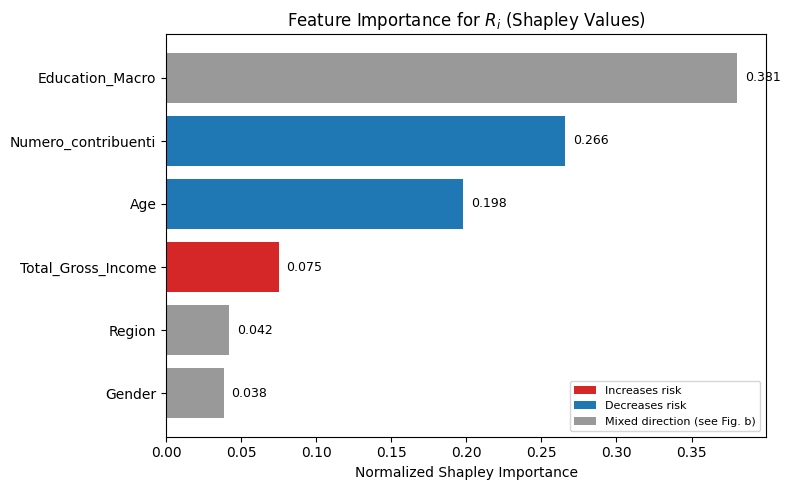

✅ Grafico 1 salvato: /content/drive/MyDrive/Paper ASMBI/Dataset/shapley_importance_Ri.pdf


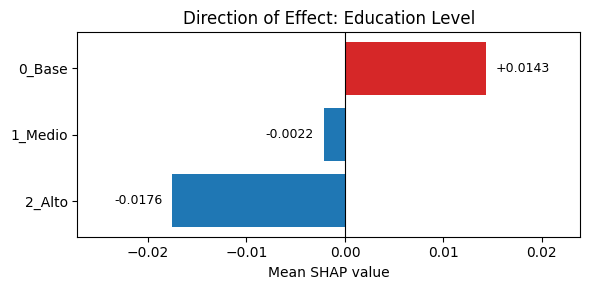

✅ Grafico 2 salvato: /content/drive/MyDrive/Paper ASMBI/Dataset/shapley_direction_education.pdf


In [ ]:
# %% CELL 4bis — Direzione dell'effetto (segno), non solo magnitudine
# =============================================================================
# I valori di Shapley hanno già un segno, calcolato nella Cella 4 (shap_values):
# positivo = spinge r_i verso l'alto (più rischio), negativo = verso il basso.
# Qui lo estraiamo esplicitamente, distinguendo variabili continue e categoriali.

print("=== VARIABILI CONTINUE: direzione tramite correlazione feature-valore/SHAP ===")
variabili_continue = ['Age', 'Total_Gross_Income', 'Numero_contribuenti']
for var in variabili_continue:
    if var in X_shap_sample.columns:
        corr = np.corrcoef(X_shap_sample[var].values,
                            shap_values[:, X_shap_sample.columns.get_loc(var)])[0, 1]
        direzione = "AUMENTA il rischio quando cresce" if corr > 0 else "DIMINUISCE il rischio quando cresce"
        print(f"{var}: correlazione feature/SHAP = {corr:+.3f} → {direzione}")

print("\n=== VARIABILI CATEGORIALI: SHAP medio quando la categoria è presente ===")
risultati_per_export = []
for base in ['Region', 'Gender', 'Education_Macro']:
    cols_categoria = [c for c in X_shap_sample.columns if c.startswith(base + '_')]
    print(f"\n--- {base} ---")
    risultati_categoria = []
    for col in cols_categoria:
        mask = X_shap_sample[col].values == 1
        if mask.sum() > 0:
            shap_medio = shap_values[mask, X_shap_sample.columns.get_loc(col)].mean()
            risultati_categoria.append((col.replace(base + '_', ''), shap_medio))
            risultati_per_export.append({'variabile': base, 'categoria': col.replace(base + '_', ''),
                                          'shap_medio': shap_medio})
    risultati_categoria.sort(key=lambda x: x[1], reverse=True)
    for nome_categoria, shap_medio in risultati_categoria:
        segno = "aumenta" if shap_medio > 0 else "diminuisce"
        print(f"  {nome_categoria}: SHAP medio = {shap_medio:+.5f} ({segno} il rischio)")

# Salvataggio: serve in R per assegnare a ogni comune il valore SHAP della sua
# regione — un lookup diretto, non uno scaling generico (Region non ha una
# "magnitudine" continua sensata come le altre feature).
df_export_categoriali = pd.DataFrame(risultati_per_export)
PATH_CATEGORIALI = '/content/drive/MyDrive/Paper ASMBI/Dataset/shap_medio_per_categoria.csv'
df_export_categoriali.to_csv(PATH_CATEGORIALI, index=False)
print(f"\n✅ Salvato: {PATH_CATEGORIALI}")

print("\n✅ Direzione degli effetti estratta — utile per la discussione nel Capitolo 5:")
print("   non solo QUALI variabili contano di più, ma in che VERSO agiscono.")



# %% CELL 4ter — Grafico dei pesi Shapley, con direzione dell'effetto
# =============================================================================
import matplotlib.pyplot as plt

# --- Direzione nota per le variabili continue (dalla Cella 4bis) ---
direzione_nota = {
    'Age': 'decrease',
    'Total_Gross_Income': 'increase',
    'Numero_contribuenti': 'decrease',
    # Categoriali: direzione MISTA all'interno del gruppo, non un singolo verso
    'Region': 'mixed',
    'Gender': 'mixed',
    'Education_Macro': 'mixed',
}
colori = {'increase': '#d62728', 'decrease': '#1f77b4', 'mixed': '#999999'}

# --- Grafico 1: importanza generale, colorata per direzione (dove univoca) ---
fig, ax = plt.subplots(figsize=(8, 5))
pesi_plot = pesi_ri.sort_values('importance_norm', ascending=True).copy()
pesi_plot['colore'] = pesi_plot['feature'].map(lambda f: colori[direzione_nota[f]])

ax.barh(pesi_plot['feature'], pesi_plot['importance_norm'], color=pesi_plot['colore'])
ax.set_xlabel('Normalized Shapley Importance')
ax.set_title('Feature Importance for $R_i$ (Shapley Values)')
for i, (feat, val) in enumerate(zip(pesi_plot['feature'], pesi_plot['importance_norm'])):
    ax.text(val + 0.005, i, f"{val:.3f}", va='center', fontsize=9)

# Legenda esplicita, incluso il significato del grigio
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colori['increase'], label='Increases risk'),
    Patch(facecolor=colori['decrease'], label='Decreases risk'),
    Patch(facecolor=colori['mixed'], label='Mixed direction (see Fig. b)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()

PATH_GRAFICO = '/content/drive/MyDrive/Paper ASMBI/Dataset/shapley_importance_Ri.pdf'
plt.savefig(PATH_GRAFICO, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Grafico 1 salvato: {PATH_GRAFICO}")

# --- Grafico 2: dettaglio direzionale di Education_Macro (la variabile mista
#     più importante, merita un grafico a sé per mostrare la direzione vera) ---
edu_data = df_export_categoriali[df_export_categoriali['variabile'] == 'Education_Macro'].copy()
edu_data = edu_data.sort_values('shap_medio')

fig2, ax2 = plt.subplots(figsize=(6, 3))
colori_edu = ['#d62728' if v > 0 else '#1f77b4' for v in edu_data['shap_medio']]
ax2.barh(edu_data['categoria'], edu_data['shap_medio'], color=colori_edu)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Mean SHAP value')
ax2.set_title('Direction of Effect: Education Level')

# Margini extra sull'asse x, altrimenti le etichette delle barre negative
# escono nello spazio dei nomi delle categorie (successo nel primo tentativo)
xmin, xmax = edu_data['shap_medio'].min(), edu_data['shap_medio'].max()
padding = (xmax - xmin) * 0.30
ax2.set_xlim(xmin - padding, xmax + padding)

# Etichette numeriche sulle barre, coerenti con il Grafico 1
for i, (cat, val) in enumerate(zip(edu_data['categoria'], edu_data['shap_medio'])):
    offset = (xmax - xmin) * 0.03
    x_text = val + offset if val > 0 else val - offset
    ha = 'left' if val > 0 else 'right'
    ax2.text(x_text, i, f"{val:+.4f}", va='center', ha=ha, fontsize=9)

plt.tight_layout()

PATH_GRAFICO_EDU = '/content/drive/MyDrive/Paper ASMBI/Dataset/shapley_direction_education.pdf'
plt.savefig(PATH_GRAFICO_EDU, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Grafico 2 salvato: {PATH_GRAFICO_EDU}")